# Coding Task: Logistic Regression from Scratch with Nonlinear Transformations

**Goal:** Implement logistic regression using gradient descent, apply it to nonlinearly separable data, and understand the effect of nonlinear transformations.

## What You Will Do

1. Generate a synthetic dataset that is **not linearly separable** (e.g., circles or XOR pattern).
2. Implement logistic regression from scratch:
   - Sigmoid function
   - Cost function (cross‑entropy)
   - Gradient descent update rules
   - Prediction function (`predict`)
3. Train the model on the raw features and evaluate accuracy.
4. Apply a **nonlinear transformation** (e.g., polynomial features) to make the data linearly separable in a higher‑dimensional space.
5. Compare performance before and after transformation.
6. Experiment with different learning rates and numbers of iterations.

## Questions to Answer

1. Why does logistic regression fail on the raw data? What is the shape of the decision boundary?
2. How does the nonlinear transformation help? What is the new decision boundary in the original space?
3. What happens if you increase the transformation degree too much (e.g., degree 10)? How does it relate to overfitting?
4. How does the learning rate affect convergence? Show plots of cost vs. iterations for different learning rates.

Training samples: 160, Test samples: 40


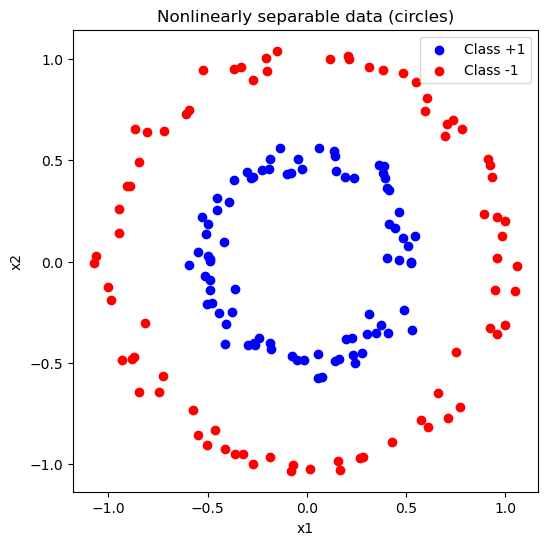

In [1]:
## Cell 1 – Imports and Data Generation

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import accuracy_score

# Generate synthetic nonlinearly separable data (two interlocking circles)
X, y = make_circles(n_samples=200, noise=0.05, factor=0.5, random_state=42)
y = y * 2 - 1   # convert labels to -1 and +1 (for consistency with PLA style)

# Split into train and test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

plt.figure(figsize=(6,6))
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], c='blue', label='Class +1')
plt.scatter(X_train[y_train==-1, 0], X_train[y_train==-1, 1], c='red', label='Class -1')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Nonlinearly separable data (circles)')
plt.legend()
plt.show()

In [ ]:
def sigmoid(z):
    """Return the sigmoid of z (1/(1+exp(-z)))."""
    # TODO: implement sigmoid
    return 1 / (1 + np.exp(-z))   # placeholder, replace with correct code

def compute_cost(X, y, w):
    """Compute cross‑entropy cost (average negative log‑likelihood)."""
    N = len(y)
    z = X @ w
    h = sigmoid(z)
    # TODO: compute cost = (1/N) * sum( -y_i*log(h_i) - (1-y_i)*log(1-h_i) )
    # Note: y_i in {+1,-1}, but sigmoid gives probability of +1. 
    # We need to map y from {-1,1} to {0,1} for the formula.
    y_01 = (y + 1) // 2   # convert -1->0, +1->1
    cost = None   # replace
    return cost

def gradient_descent(X, y, w, learning_rate, n_iterations):
    """Update weights using gradient descent. Return final weights and cost history."""
    N = len(y)
    cost_history = []
    for i in range(n_iterations):
        z = X @ w
        h = sigmoid(z)
        y_01 = (y + 1) // 2
        # Gradient: (1/N) * X^T (h - y_01)
        # TODO: compute gradient
        grad = None   # replace
        w = w - learning_rate * grad
        cost = compute_cost(X, y, w)
        cost_history.append(cost)
        if i % 100 == 0:
            print(f"Iteration {i}, cost = {cost:.6f}")
    return w, cost_history

def predict(X, w, threshold=0.5):
    """Predict class labels (+1 or -1) for samples in X.
       If sigmoid(z) >= threshold -> +1, else -1.
    """
    # TODO: implement prediction
    pass

In [ ]:
# Add bias column (x0 = 1) to training and test sets
X_train_aug = np.c_[np.ones(X_train.shape[0]), X_train]
X_test_aug = np.c_[np.ones(X_test.shape[0]), X_test]

# Initialize weights to zeros
w = np.zeros(X_train_aug.shape[1])

# Hyperparameters (students can change these)
learning_rate = 0.1
n_iterations = 1000

# Train
w_final, cost_hist = gradient_descent(X_train_aug, y_train, w, learning_rate, n_iterations)

# Evaluate training and test accuracy
y_train_pred = predict(X_train_aug, w_final)
y_test_pred = predict(X_test_aug, w_final)

train_acc = accuracy_score((y_train+1)//2, (y_train_pred+1)//2)
test_acc = accuracy_score((y_test+1)//2, (y_test_pred+1)//2)
print(f"Training accuracy: {train_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

# Plot cost history
plt.plot(cost_hist)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost vs. Iterations (raw features)')
plt.show()

In [ ]:
# Function to plot decision boundary (for 2D features)
def plot_decision_boundary(X, y, w, title):
    x1_min, x1_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
    x2_min, x2_max = X[:,1].min() - 0.5, X[:,1].max() + 0.5
    xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 200),
                           np.linspace(x2_min, x2_max, 200))
    grid = np.c_[np.ones(xx1.ravel().shape[0]), xx1.ravel(), xx2.ravel()]
    Z = predict(grid, w)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, levels=[-1,0,1], colors=['red','blue'])
    plt.scatter(X[y==1,0], X[y==1,1], c='blue', edgecolor='k', label='+1')
    plt.scatter(X[y==-1,0], X[y==-1,1], c='red', edgecolor='k', label='-1')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(title)
    plt.legend()
    plt.show()

plot_decision_boundary(X_train, y_train, w_final, 'Logistic Regression on Raw Features')

In [ ]:
# Use PolynomialFeatures to create higher‑degree features
degree = 2   # try degree 2, 3, etc.
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Add bias column again
X_train_poly_aug = np.c_[np.ones(X_train_poly.shape[0]), X_train_poly]
X_test_poly_aug = np.c_[np.ones(X_test_poly.shape[0]), X_test_poly]

# Train logistic regression on transformed features
w_poly = np.zeros(X_train_poly_aug.shape[1])
w_poly_final, cost_hist_poly = gradient_descent(X_train_poly_aug, y_train, w_poly, learning_rate, n_iterations)

# Evaluate
y_train_pred_poly = predict(X_train_poly_aug, w_poly_final)
y_test_pred_poly = predict(X_test_poly_aug, w_poly_final)
train_acc_poly = accuracy_score((y_train+1)//2, (y_train_pred_poly+1)//2)
test_acc_poly = accuracy_score((y_test+1)//2, (y_test_pred_poly+1)//2)
print(f"Transformed features - Training accuracy: {train_acc_poly:.4f}")
print(f"Transformed features - Test accuracy: {test_acc_poly:.4f}")

# Plot cost history
plt.plot(cost_hist_poly)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost vs. Iterations (polynomial features)')
plt.show()

In [ ]:
learning_rates = [0.01, 0.1, 0.5, 1.0]
plt.figure(figsize=(10,6))
for lr in learning_rates:
    w = np.zeros(X_train_poly_aug.shape[1])
    _, cost_hist = gradient_descent(X_train_poly_aug, y_train, w, lr, 500)
    plt.plot(cost_hist, label=f'lr = {lr}')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Effect of Learning Rate on Convergence')
plt.legend()
plt.show()

## Questions to Answer (write your answers below)

1. **Why does logistic regression fail on the raw data? What is the shape of the decision boundary?**  
   *(Hint: Look at the plot of the raw data. Is it linearly separable?)*

2. **How does the nonlinear transformation help?**  
   *(Hint: Compare the test accuracy before and after transformation. What happens to the decision boundary in the original space?)*

3. **What happens if you increase the transformation degree too much (e.g., degree = 10)?**  
   *(Try it in Cell 4 by changing `degree` and observe training vs test accuracy. Does overfitting occur?)*

4. **How does the learning rate affect convergence?**  
   *(Look at the cost vs. iterations plot for different learning rates. Which rate works best? What happens if the rate is too large?)*